# 🔄 Sistem Klasifikasi Retur Otomatis

**Tujuan:** Mengklasifikasikan pengajuan retur dari pembeli menjadi:
- ✅ **VALID** → Pengajuan layak diterima
- ❌ **TIDAK VALID** → Pengajuan ditolak
- 🔍 **PERLU DICEK** → Ada indikasi lampiran (foto/video/bukti) yang perlu diverifikasi manual

**Fitur yang digunakan:**
- Alasan Pengembalian
- Catatan Pengembalian Barang
- Selisih hari antara Tanggal Pesanan → Waktu Pengajuan Retur

**Label mapping dari data historis:**
- `Dana Dikembalikan ke Pembeli` → **VALID**
- `Banding Ditolak` → **TIDAK VALID**
- `Dana Dicairkan ke Penjual` → **TIDAK VALID**
- `Pengajuan Ditolak` → **TIDAK VALID**
- `Pengembalian Barang/Dana Dibatalkan` → **Dihapus dari training** (pembeli sendiri yang batalkan, bukan keputusan sistem)

## 📦 1. Import Library

In [7]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 📂 2. Load Data

In [9]:
# Sesuaikan path file
FILE_PATH = 'hasil_gabungan.xlsx'

df_raw = pd.read_excel(FILE_PATH)
print(f'✅ Data berhasil dimuat: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom')
df_raw.head(3)

✅ Data berhasil dimuat: 1501 baris, 46 kolom


,No. Pengembalian,No. Pesanan,Tanggal Pesanan Dibuat,Username (Pembeli),Nama Produk,SKU Induk,Variasi,Kode Variasi,Harga Satuan,Waktu Pengembalian Diajukan,...,Jumlah Kompensasi,Pilihan Jasa Kirim Pengiriman Terusan,No. Resi Pengiriman Terusan,Total Pesanan,Metode Pembayaran,Catatan Pembeli untuk Pesanan,Pelepasan Dana,Ongkos Kirim Pengiriman,Ongkos Kirim Pengembalian,Penyesuaian Alasan Pengembalian
0,2402040N66MYV6B,240123MK25Y0Q1,2024-01-23 18:14,k******o,Micro SD SANDISK Ultra 64GB Class 10 100MB/s -...,MSS001,NaN,NaN,RP 79.000\n,2024-02-04 13:43,...,RP 0\n,Hemat,SPXID043907675661,RP 80.000\n,NaN,NaN,RP 0\n,RP 0\n,RP 0\n,NaN
1,2402040NDBNY4WM,240201DKVJ4X0T,2024-02-01 13:27,a******1,LAN Card TP-Link TG-3468 Gigabit PCI Express N...,HLAWT06.P,NaN,NaN,RP 122.000\n,2024-02-04 15:51,...,-,Hemat,10008333268922,RP 123.000\n,NaN,NaN,RP 110.410\n,RP -16.500\n,RP 0\n,NaN
2,2402060ST3F48UD,240131AM3XUSFD,2024-01-31 08:53,anwarwuns99,LED Monitor Viewsonic TD2223 21.5 Inch Full HD...,LMV018,NaN,NaN,RP 3.310.000\n,2024-02-06 09:50,...,-,Kargo,JT84037980953,RP 3.311.000\n,NaN,NaN,RP 3.167.600\n,RP -38.501\n,RP 0\n,NaN


## 🔍 3. Exploratory Data Analysis (EDA)

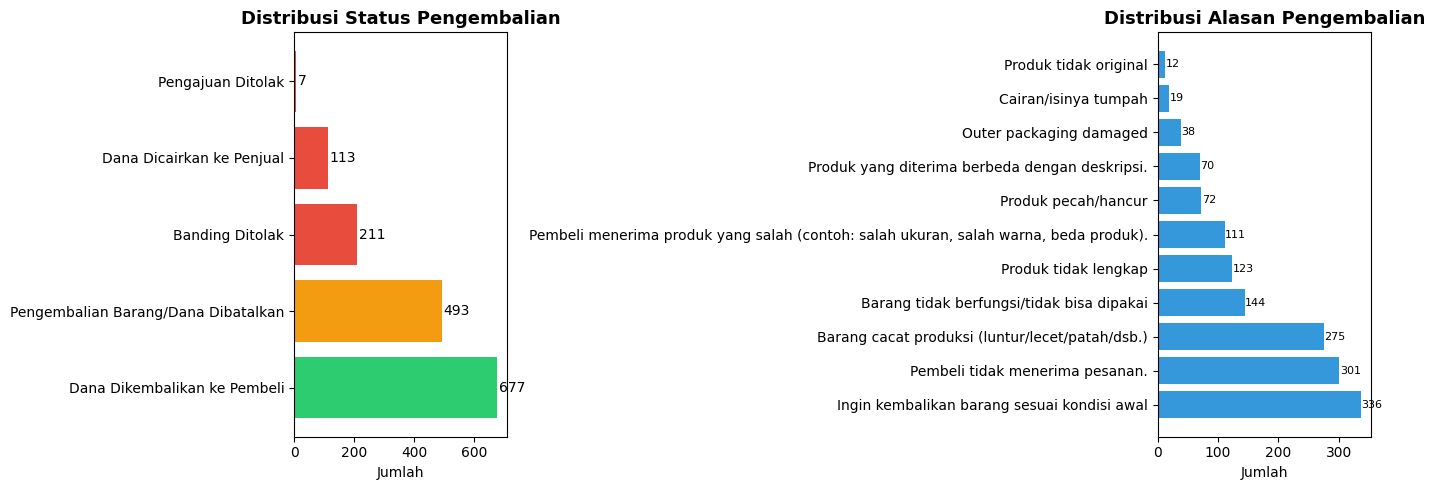


Distribusi Status:
Status Pembatalan/ Pengembalian
Dana Dikembalikan ke Pembeli           677
Pengembalian Barang/Dana Dibatalkan    493
Banding Ditolak                        211
Dana Dicairkan ke Penjual              113
Pengajuan Ditolak                        7
Name: count, dtype: int64


In [10]:
# Distribusi Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = df_raw['Status Pembatalan/ Pengembalian'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#e74c3c', '#e74c3c', '#f39c12']
axes[0].barh(status_counts.index, status_counts.values, color=['#2ecc71','#f39c12','#e74c3c','#e74c3c','#e74c3c'])
axes[0].set_title('Distribusi Status Pengembalian', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah')
for i, v in enumerate(status_counts.values):
    axes[0].text(v + 5, i, str(v), va='center')

alasan_counts = df_raw['Alasan Pengembalian'].value_counts()
axes[1].barh(alasan_counts.index, alasan_counts.values, color='#3498db')
axes[1].set_title('Distribusi Alasan Pengembalian', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah')
for i, v in enumerate(alasan_counts.values):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=100, bbox_inches='tight')
plt.show()
print('\nDistribusi Status:')
print(status_counts)

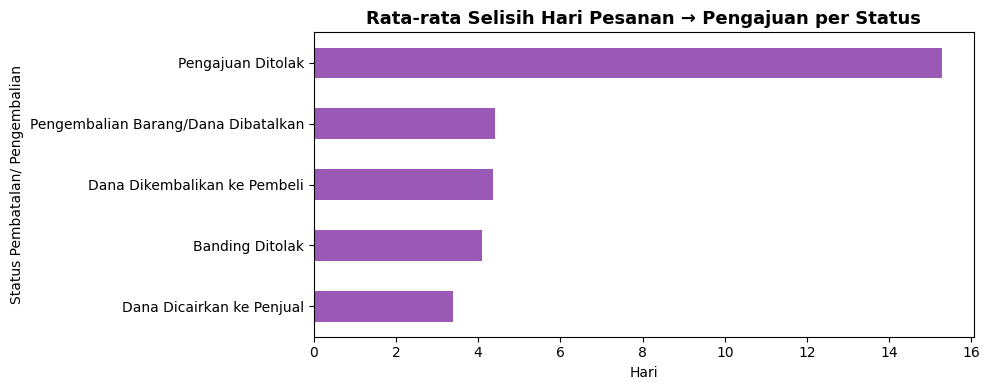


Statistik selisih hari:
                                     count   mean   std  min   25%   50%  \
Status Pembatalan/ Pengembalian                                            
Banding Ditolak                      211.0   4.09  3.98  0.0   1.0   3.0   
Dana Dicairkan ke Penjual            113.0   3.40  3.81  0.0   1.0   3.0   
Dana Dikembalikan ke Pembeli         677.0   4.37  4.53  0.0   1.0   3.0   
Pengajuan Ditolak                      7.0  15.29  9.79  1.0  10.0  14.0   
Pengembalian Barang/Dana Dibatalkan  493.0   4.41  4.37  0.0   1.0   3.0   

                                      75%   max  
Status Pembatalan/ Pengembalian                  
Banding Ditolak                       5.0  21.0  
Dana Dicairkan ke Penjual             4.0  21.0  
Dana Dikembalikan ke Pembeli          6.0  28.0  
Pengajuan Ditolak                    22.5  27.0  
Pengembalian Barang/Dana Dibatalkan   6.0  24.0  


In [11]:
# Analisis selisih hari
df_raw['Tanggal Pesanan Dibuat'] = pd.to_datetime(df_raw['Tanggal Pesanan Dibuat'])
df_raw['Waktu Pengembalian Diajukan'] = pd.to_datetime(df_raw['Waktu Pengembalian Diajukan'])
df_raw['selisih_hari'] = (df_raw['Waktu Pengembalian Diajukan'] - df_raw['Tanggal Pesanan Dibuat']).dt.days

fig, ax = plt.subplots(figsize=(10, 4))
df_raw.groupby('Status Pembatalan/ Pengembalian')['selisih_hari'].mean().sort_values().plot(
    kind='barh', ax=ax, color='#9b59b6'
)
ax.set_title('Rata-rata Selisih Hari Pesanan → Pengajuan per Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Hari')
plt.tight_layout()
plt.savefig('eda_selisih_hari.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nStatistik selisih hari:')
print(df_raw.groupby('Status Pembatalan/ Pengembalian')['selisih_hari'].describe().round(2))

## 🏷️ 4. Label Engineering

Mapping status ke label:
- **VALID** = `Dana Dikembalikan ke Pembeli`
- **TIDAK VALID** = `Banding Ditolak`, `Dana Dicairkan ke Penjual`, `Pengajuan Ditolak`
- **Dibuang** = `Pengembalian Barang/Dana Dibatalkan` (pembeli sendiri yang batalkan, bukan keputusan sistem)

In [12]:
LABEL_MAP = {
    'Dana Dikembalikan ke Pembeli': 'VALID',
    'Banding Ditolak': 'TIDAK VALID',
    'Dana Dicairkan ke Penjual': 'TIDAK VALID',
    'Pengajuan Ditolak': 'TIDAK VALID',
}

df_raw['label'] = df_raw['Status Pembatalan/ Pengembalian'].map(LABEL_MAP)
df_labeled = df_raw.dropna(subset=['label']).copy()

print(f'Data setelah filtering: {len(df_labeled)} baris')
print(f'Data dibuang (Dibatalkan pembeli): {len(df_raw) - len(df_labeled)} baris')
print('\nDistribusi label:')
print(df_labeled['label'].value_counts())
print(f'\nRasio: {df_labeled["label"].value_counts(normalize=True).round(3) * 100}')

Data setelah filtering: 1008 baris
Data dibuang (Dibatalkan pembeli): 493 baris

Distribusi label:
label
VALID          677
TIDAK VALID    331
Name: count, dtype: int64

Rasio: label
VALID          67.2
TIDAK VALID    32.8
Name: proportion, dtype: float64


## ⚙️ 5. Feature Engineering

In [13]:
# Keyword yang mengindikasikan lampiran visual (untuk flag 'PERLU DICEK')
KEYWORD_LAMPIRAN = [
    'foto', 'video', 'bukti', 'lampir', 'gambar', 'rekam', 'ss', 'screenshot',
    'tangkap layar', 'dokumentasi', 'unboxing', 'capture', 'file', 'attachment'
]

# Alasan yang WAJIB perlu bukti visual (jika catatan kosong → flag Perlu Dicek)
ALASAN_BUTUH_BUKTI = [
    'Barang cacat produksi (luntur/lecet/patah/dsb.)',
    'Barang tidak berfungsi/tidak bisa dipakai',
    'Produk pecah/hancur',
    'Produk yang diterima berbeda dengan deskripsi.',
    'Cairan/isinya tumpah',
    'Outer packaging damaged',
    'Produk tidak original',
]

def extract_features(df):
    """Extract all features dari dataframe retur"""
    df = df.copy()
    
    # 1. Parse datetime
    df['Tanggal Pesanan Dibuat'] = pd.to_datetime(df['Tanggal Pesanan Dibuat'], errors='coerce')
    df['Waktu Pengembalian Diajukan'] = pd.to_datetime(df['Waktu Pengembalian Diajukan'], errors='coerce')
    
    # 2. Selisih hari
    df['selisih_hari'] = (df['Waktu Pengembalian Diajukan'] - df['Tanggal Pesanan Dibuat']).dt.days.fillna(0).clip(0, 90)
    
    # 3. Bersihkan catatan
    df['catatan_bersih'] = df['Catatan Pengembalian Barang'].fillna('').str.lower().str.strip()
    
    # 4. Flag lampiran dari catatan
    df['ada_keyword_lampiran'] = df['catatan_bersih'].apply(
        lambda x: 1 if any(kw in x for kw in KEYWORD_LAMPIRAN) else 0
    )
    
    # 5. Flag catatan kosong
    df['catatan_kosong'] = (df['catatan_bersih'] == '').astype(int)
    
    # 6. Panjang catatan
    df['panjang_catatan'] = df['catatan_bersih'].str.len()
    
    # 7. Alasan butuh bukti
    df['alasan_butuh_bukti'] = df['Alasan Pengembalian'].isin(ALASAN_BUTUH_BUKTI).astype(int)
    
    # 8. Flag Perlu Dicek:
    # Kondisi: (catatan menyebut foto/video/bukti) ATAU (alasan butuh bukti & catatan kosong)
    df['perlu_dicek'] = (
        (df['ada_keyword_lampiran'] == 1) |
        ((df['alasan_butuh_bukti'] == 1) & (df['catatan_kosong'] == 1))
    ).astype(int)
    
    # 9. Tipe pengembalian binary
    df['tipe_seluruh'] = (df['Tipe Pengembalian'] == 'Seluruh Pesanan').astype(int)
    
    # 10. Alasan encode numerik
    alasan_map = {
        'Pembeli tidak menerima pesanan.': 1,
        'Ingin kembalikan barang sesuai kondisi awal': 2,
        'Barang cacat produksi (luntur/lecet/patah/dsb.)': 3,
        'Barang tidak berfungsi/tidak bisa dipakai': 4,
        'Produk tidak lengkap': 5,
        'Pembeli menerima produk yang salah (contoh: salah ukuran, salah warna, beda produk).': 6,
        'Produk pecah/hancur': 7,
        'Produk yang diterima berbeda dengan deskripsi.': 8,
        'Outer packaging damaged': 9,
        'Cairan/isinya tumpah': 10,
        'Produk tidak original': 11,
    }
    df['alasan_kode'] = df['Alasan Pengembalian'].map(alasan_map).fillna(0)
    
    return df

df_feat = extract_features(df_labeled)

print('✅ Feature engineering selesai')
print(f"\nPerlu Dicek flags: {df_feat['perlu_dicek'].sum()} ({df_feat['perlu_dicek'].mean()*100:.1f}%)")
print(f"  - Dari keyword lampiran di catatan: {df_feat['ada_keyword_lampiran'].sum()}")
print(f"  - Dari alasan butuh bukti & catatan kosong: {((df_feat['alasan_butuh_bukti']==1)&(df_feat['catatan_kosong']==1)).sum()}")

✅ Feature engineering selesai

Perlu Dicek flags: 192 (19.0%)
  - Dari keyword lampiran di catatan: 127
  - Dari alasan butuh bukti & catatan kosong: 65


## 🤖 6. Training Model Klasifikasi (Valid / Tidak Valid)

In [14]:
# Pisahkan data untuk training (yang PERLU DICEK tidak dimasukkan ke training model ML)
# karena mereka nanti langsung di-flag manual
df_train = df_feat[df_feat['perlu_dicek'] == 0].copy()

print(f'Data untuk training (tanpa Perlu Dicek): {len(df_train)} baris')
print(df_train['label'].value_counts())

Data untuk training (tanpa Perlu Dicek): 816 baris
label
VALID          561
TIDAK VALID    255
Name: count, dtype: int64


In [15]:
# TF-IDF pada gabungan alasan + catatan
df_train['teks_gabungan'] = (
    df_train['Alasan Pengembalian'].fillna('') + ' ' +
    df_train['catatan_bersih']
).str.lower()

# Encode label
le = LabelEncoder()
y = le.fit_transform(df_train['label'])  # 0=TIDAK VALID, 1=VALID

# Numerical features
num_features = ['selisih_hari', 'alasan_kode', 'panjang_catatan', 'tipe_seluruh', 'alasan_butuh_bukti']
X_num = df_train[num_features].values

# TF-IDF features
tfidf = TfidfVectorizer(max_features=200, ngram_range=(1,2), min_df=2)
X_tfidf = tfidf.fit_transform(df_train['teks_gabungan'])

# Gabungkan
X = sp.hstack([X_tfidf, sp.csr_matrix(X_num)])

print(f'Shape fitur: {X.shape}')
print(f'Label classes: {le.classes_}')

Shape fitur: (816, 205)
Label classes: ['TIDAK VALID' 'VALID']


In [16]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train distribution: {dict(zip(le.classes_, np.bincount(y_train)))}')
print(f'Test distribution: {dict(zip(le.classes_, np.bincount(y_test)))}')

Train: 652 | Test: 164
Train distribution: {'TIDAK VALID': np.int64(204), 'VALID': np.int64(448)}
Test distribution: {'TIDAK VALID': np.int64(51), 'VALID': np.int64(113)}


In [17]:
# Training 3 model dan bandingkan
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=4),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=1.0)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'test_accuracy': test_acc,
        'y_pred': y_pred
    }
    print(f'\n📊 {name}')
    print(f'   CV F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'   Test Accuracy: {test_acc:.4f}')


📊 Random Forest
   CV F1 (5-fold): 0.7100 ± 0.0280
   Test Accuracy: 0.7317

📊 Gradient Boosting
   CV F1 (5-fold): 0.7030 ± 0.0178
   Test Accuracy: 0.7134

📊 Logistic Regression
   CV F1 (5-fold): 0.6666 ± 0.0249
   Test Accuracy: 0.6707


🏆 Model terbaik: Random Forest

Classification Report:
              precision    recall  f1-score   support

 TIDAK VALID       0.59      0.47      0.52        51
       VALID       0.78      0.85      0.81       113

    accuracy                           0.73       164
   macro avg       0.68      0.66      0.67       164
weighted avg       0.72      0.73      0.72       164



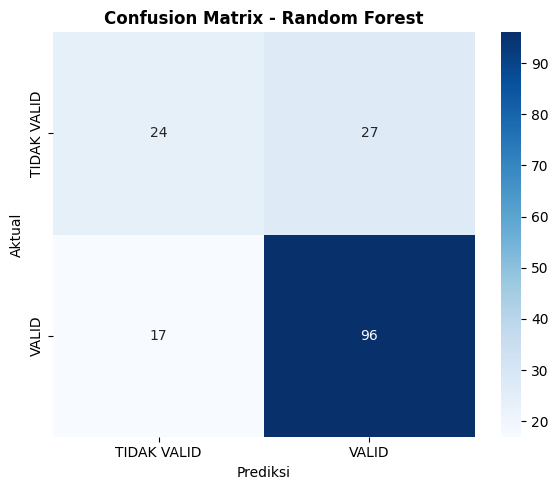

In [18]:
# Pilih model terbaik berdasarkan CV F1
best_name = max(results, key=lambda k: results[k]['cv_f1_mean'])
best_model = results[best_name]['model']
print(f'🏆 Model terbaik: {best_name}')

# Classification report
y_pred_best = results[best_name]['y_pred']
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix - {best_name}', fontweight='bold')
ax.set_ylabel('Aktual')
ax.set_xlabel('Prediksi')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

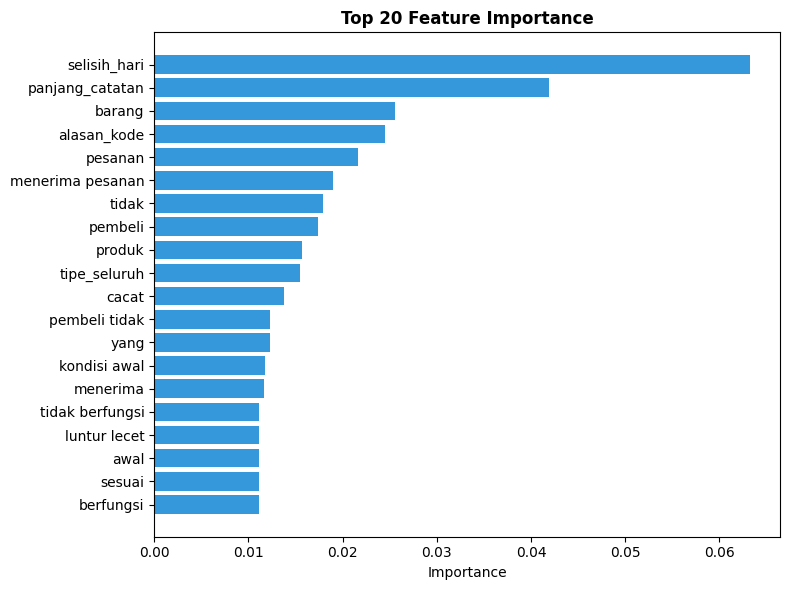

In [19]:
# Feature importance (untuk Random Forest / GB)
if hasattr(best_model, 'feature_importances_'):
    tfidf_names = tfidf.get_feature_names_out().tolist()
    all_feature_names = tfidf_names + num_features
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[-20:]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh([all_feature_names[i] for i in top_idx], importances[top_idx], color='#3498db')
    ax.set_title('Top 20 Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()

## 🕵️ 7. Deteksi Customer "Nakal" (Anomaly Detection)

In [20]:
# Hitung statistik per customer dari SEMUA data (bukan hanya training)
df_all = extract_features(df_raw)

customer_stats = df_all.groupby('Username (Pembeli)').agg(
    total_retur=('No. Pengembalian', 'count'),
    avg_selisih_hari=('selisih_hari', 'mean'),
    pct_tidak_valid=('label', lambda x: (x == 'TIDAK VALID').mean()),
    total_nilai_retur=('Total Pengembalian Dana', lambda x: x.apply(
        lambda v: float(str(v).replace('RP','').replace('.','').replace(',','').replace('\\n','').strip())
        if pd.notna(v) else 0
    ).sum()),
    alasan_unik=('Alasan Pengembalian', 'nunique'),
    pct_catatan_kosong=('catatan_kosong', 'mean'),
).reset_index()

# Hanya analisis customer yang retur >= 2 kali
customer_multi = customer_stats[customer_stats['total_retur'] >= 2].copy()
print(f'Customer dengan retur >= 2x: {len(customer_multi)} orang')

# Isolation Forest untuk anomaly detection
iso_features = ['total_retur', 'avg_selisih_hari', 'pct_tidak_valid', 'alasan_unik', 'pct_catatan_kosong']
X_iso = customer_multi[iso_features].fillna(0).values

iso_model = IsolationForest(contamination=0.1, random_state=42)
customer_multi['anomaly_score'] = iso_model.fit_predict(X_iso)
customer_multi['anomaly_raw_score'] = iso_model.score_samples(X_iso)
customer_multi['is_suspicious'] = (customer_multi['anomaly_score'] == -1).astype(int)

suspicious = customer_multi[customer_multi['is_suspicious'] == 1].sort_values('anomaly_raw_score')
print(f'\n🚨 Terdeteksi {len(suspicious)} customer mencurigakan:')
print(suspicious[['Username (Pembeli)', 'total_retur', 'avg_selisih_hari', 
                   'pct_tidak_valid', 'alasan_unik', 'pct_catatan_kosong']].head(15).to_string(index=False))

Customer dengan retur >= 2x: 305 orang

🚨 Terdeteksi 31 customer mencurigakan:
Username (Pembeli)  total_retur  avg_selisih_hari  pct_tidak_valid  alasan_unik  pct_catatan_kosong
          a******a           28          6.892857         0.250000            9            0.285714
          r******a           19          3.631579         0.052632            9            0.105263
    leafieofficial            2          3.000000         1.000000            1            1.000000
          a******i           17          4.000000         0.235294            8            0.117647
            g****7            2         14.000000         0.000000            1            1.000000
            a****1            4         23.000000         0.000000            1            0.000000
          b******s            5         14.000000         0.000000            2            0.800000
          a******1           15          4.800000         0.066667            6            0.200000
           i*****5   

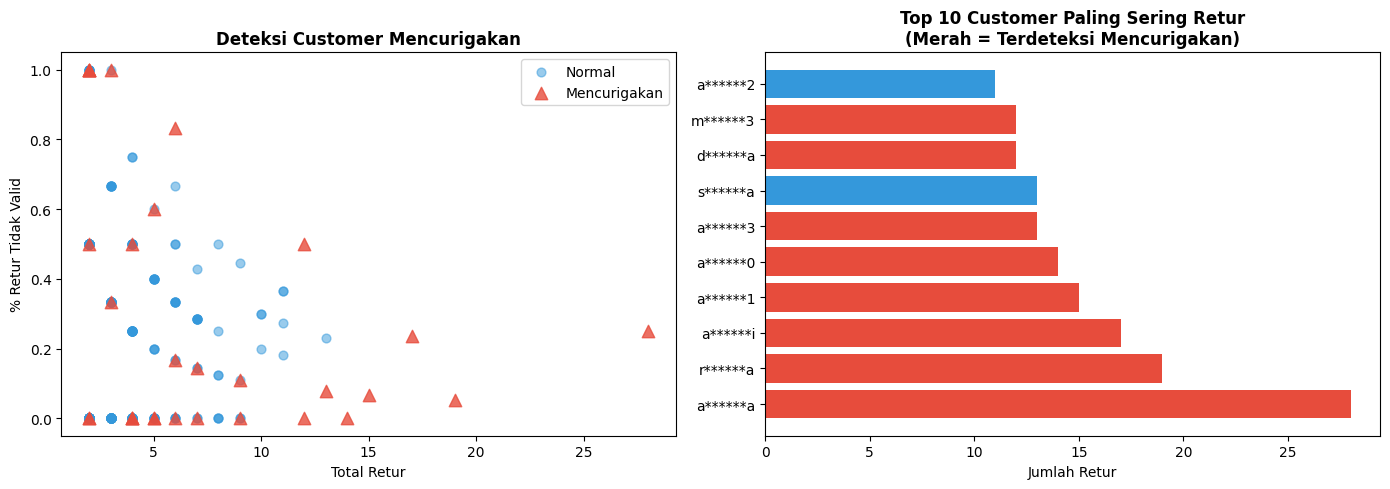

In [21]:
# Visualisasi customer nakal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: total retur vs % tidak valid
normal = customer_multi[customer_multi['is_suspicious'] == 0]
anomaly = customer_multi[customer_multi['is_suspicious'] == 1]

axes[0].scatter(normal['total_retur'], normal['pct_tidak_valid'], 
                alpha=0.5, color='#3498db', label='Normal', s=40)
axes[0].scatter(anomaly['total_retur'], anomaly['pct_tidak_valid'], 
                alpha=0.8, color='#e74c3c', label='Mencurigakan', s=80, marker='^')
axes[0].set_xlabel('Total Retur')
axes[0].set_ylabel('% Retur Tidak Valid')
axes[0].set_title('Deteksi Customer Mencurigakan', fontweight='bold')
axes[0].legend()

# Top 10 customer dengan retur terbanyak
top10 = customer_stats.nlargest(10, 'total_retur')
colors_bar = ['#e74c3c' if u in suspicious['Username (Pembeli)'].values else '#3498db' 
              for u in top10['Username (Pembeli)']]
axes[1].barh(top10['Username (Pembeli)'], top10['total_retur'], color=colors_bar)
axes[1].set_title('Top 10 Customer Paling Sering Retur\n(Merah = Terdeteksi Mencurigakan)', fontweight='bold')
axes[1].set_xlabel('Jumlah Retur')

plt.tight_layout()
plt.savefig('customer_nakal.png', dpi=100, bbox_inches='tight')
plt.show()

## 💾 8. Simpan Model

In [22]:
# Simpan semua komponen yang dibutuhkan Streamlit
model_bundle = {
    'model': best_model,
    'model_name': best_name,
    'tfidf': tfidf,
    'label_encoder': le,
    'num_features': num_features,
    'keyword_lampiran': KEYWORD_LAMPIRAN,
    'alasan_butuh_bukti': ALASAN_BUTUH_BUKTI,
    'iso_model': iso_model,
    'customer_stats': customer_stats,
}

joblib.dump(model_bundle, 'model_retur.pkl')
print(f'✅ Model disimpan: model_retur.pkl')
print(f'   Model: {best_name}')
print(f'   CV F1: {results[best_name]["cv_f1_mean"]:.4f}')
print(f'   Test Accuracy: {results[best_name]["test_accuracy"]:.4f}')

✅ Model disimpan: model_retur.pkl
   Model: Random Forest
   CV F1: 0.7100
   Test Accuracy: 0.7317


## 🧪 9. Test Prediksi Manual

In [23]:
def predict_return(alasan, catatan, tanggal_pesanan, waktu_pengajuan, tipe='Seluruh Pesanan'):
    """Prediksi satu pengajuan retur"""
    catatan_lower = str(catatan).lower().strip() if pd.notna(catatan) else ''
    ada_lampiran = int(any(kw in catatan_lower for kw in KEYWORD_LAMPIRAN))
    catatan_kosong_flag = int(catatan_lower == '')
    alasan_butuh_bukti_flag = int(alasan in ALASAN_BUTUH_BUKTI)
    perlu_dicek_flag = ada_lampiran or (alasan_butuh_bukti_flag and catatan_kosong_flag)
    
    if perlu_dicek_flag:
        if ada_lampiran:
            alasan_perlu_dicek = f"Catatan menyebut lampiran visual: '{catatan_lower[:80]}..."
        else:
            alasan_perlu_dicek = f"Alasan '{alasan}' butuh bukti visual tapi catatan kosong"
        return 'PERLU DICEK', 0.0, alasan_perlu_dicek
    
    tgl = pd.to_datetime(tanggal_pesanan)
    wkt = pd.to_datetime(waktu_pengajuan)
    selisih = max(0, (wkt - tgl).days)
    
    alasan_map_local = {
        'Pembeli tidak menerima pesanan.': 1,
        'Ingin kembalikan barang sesuai kondisi awal': 2,
        'Barang cacat produksi (luntur/lecet/patah/dsb.)': 3,
        'Barang tidak berfungsi/tidak bisa dipakai': 4,
        'Produk tidak lengkap': 5,
        'Pembeli menerima produk yang salah (contoh: salah ukuran, salah warna, beda produk).': 6,
        'Produk pecah/hancur': 7,
        'Produk yang diterima berbeda dengan deskripsi.': 8,
        'Outer packaging damaged': 9,
        'Cairan/isinya tumpah': 10,
        'Produk tidak original': 11,
    }
    
    teks = (alasan + ' ' + catatan_lower).lower()
    X_tfidf_pred = tfidf.transform([teks])
    X_num_pred = np.array([[
        selisih,
        alasan_map_local.get(alasan, 0),
        len(catatan_lower),
        int(tipe == 'Seluruh Pesanan'),
        alasan_butuh_bukti_flag
    ]])
    X_pred = sp.hstack([X_tfidf_pred, sp.csr_matrix(X_num_pred)])
    pred = best_model.predict(X_pred)[0]
    proba = best_model.predict_proba(X_pred)[0].max()
    label_pred = le.inverse_transform([pred])[0]
    return label_pred, proba, f'Confidence: {proba:.1%}'

# Test cases
test_cases = [
    ('Pembeli tidak menerima pesanan.', 'sudah sebulan belum sampai', '2024-01-01', '2024-02-01'),
    ('Barang cacat produksi (luntur/lecet/patah/dsb.)', 'ada foto bukti kerusakannya saya lampirkan', '2024-01-15', '2024-01-20'),
    ('Ingin kembalikan barang sesuai kondisi awal', '', '2024-01-10', '2024-01-12'),
    ('Barang cacat produksi (luntur/lecet/patah/dsb.)', '', '2024-01-10', '2024-01-12'),
]

print('🧪 Test Prediksi:\n')
for alasan, catatan, tgl_pesan, tgl_retur in test_cases:
    hasil, conf, note = predict_return(alasan, catatan, tgl_pesan, tgl_retur)
    icon = '✅' if hasil == 'VALID' else ('🔍' if hasil == 'PERLU DICEK' else '❌')
    print(f'{icon} {hasil} | {note}')
    print(f'   Alasan: {alasan}')
    print(f'   Catatan: "{catatan}"')
    print()

🧪 Test Prediksi:

✅ VALID | Confidence: 99.0%
   Alasan: Pembeli tidak menerima pesanan.
   Catatan: "sudah sebulan belum sampai"

🔍 PERLU DICEK | Catatan menyebut lampiran visual: 'ada foto bukti kerusakannya saya lampirkan...
   Alasan: Barang cacat produksi (luntur/lecet/patah/dsb.)
   Catatan: "ada foto bukti kerusakannya saya lampirkan"

❌ TIDAK VALID | Confidence: 85.7%
   Alasan: Ingin kembalikan barang sesuai kondisi awal
   Catatan: ""

🔍 PERLU DICEK | Alasan 'Barang cacat produksi (luntur/lecet/patah/dsb.)' butuh bukti visual tapi catatan kosong
   Alasan: Barang cacat produksi (luntur/lecet/patah/dsb.)
   Catatan: ""



## ✅ 10. Summary

Semua komponen sudah siap:
- `model_retur.pkl` → digunakan oleh Streamlit app
- `app_retur.py` → Streamlit application

**Cara menjalankan Streamlit:**
```bash
streamlit run app_retur.py
```